# Notebook 6: RL-DOHO v2 on the rheumatic and autoimmune disease dataset (published DO/HO, gain reward)

This notebook reruns the clinical comparison of Notebooks 1 and 4 with the published DO and HO and the gain-based bandit reward. Everything else is unchanged:
- **Data:** 12,085 patients, 14 features, 7 classes, the same fixed 80/20 split.
- **Fitness:** XGBoost + HistGradientBoosting with SMOTE inside 3-fold CV, on a 4,000-patient subsample.
- **Test evaluation:** 200-tree models.
- **Seeds:** 0–9.
- **Budget:** 252 fitness evaluations per run (12 agents × 21).

**Sparse initialisation (change 3) does not apply here.** With *D* = 14 the dense start is used, as fixed in the plan.

**Methods:**
- **Rerun here:** DO, HO and DOHO (all now as published) and RL-DOHO v2.
- **Reused from Notebook 4:** GA, BPSO, BGWO, LASSO, mRMR, ReliefF and all features. None of them depends on the changes, and their budget (252 evaluations) and fitness are identical. Set `RERUN_GA_BPSO_BGWO = True` to rerun the three wrappers with this notebook's code.
- **Shown for reference:** the old simplified DO/HO/DOHO/RL-DOHO from Notebook 1.

**Runtime:**
- The fitness cache from Notebooks 1 and 4 is reused, so only new subsets cost time, about 2 s each on Colab.
- There are at most 16,383 subsets, and the earlier notebooks evaluated over 4,000 of them.
- Expect 1–4 hours in total. Every run is saved as soon as it finishes.

### Fixed plan (written before any run of this notebook; all outcomes are reported)

**What changes compared with Notebooks 1–5**
1. **Published DO and HO.**
   - **DO** follows Zhao et al. (2022). Every iteration runs the rising stage (spiral move towards a random point, or the shrink step in "rainy weather"), then the descending stage (Brownian motion around the population mean), then the landing stage (Lévy flight around the elite).
   - **HO** follows Amiri et al. (2024). Phase 1 updates the first half of the population (male and female/immature candidates). Phase 2 is the defence against predators for the second half. Phase 3 is the escape inside shrinking local bounds for all agents, with greedy selection throughout.
   - These replace the simplified three-phase rules used before.
2. **Gain-based reward** for the bandit:
   - *r* = 0.8 · min(1, *g* / *g*_max) + 0.2 · share
   - *g* = fitness gain of the best subset per fitness evaluation spent. Parsimony-only moves give *g* = 0.
   - *g*_max = the largest *g* seen so far in the run.
   - share = the fraction of the arm's candidates that beat the previous population median.
   - The old reward (1 for any accepted change) is kept as an ablation.
3. **Sparse initial subsets** for every wrapper method when *D* > 100. Each agent keeps a log-uniform fraction of the features, between 10 features and 10% of them. Dense initialisation (about 50% of features) is kept as an ablation.

**Budget**
- Budgets are counted in **fitness evaluations**, equal for every method and equal to Notebooks 1–5 (POP × 21 for the rheumatic data, POP × 51 for gene data).
- The published HO evaluates about 3 × POP candidates per iteration, so it runs fewer iterations within the same budget.

**RL-DOHO settings (unchanged, not tuned):** κ = 2 stagnant iterations, tie band ε = 0.001, UCB c = 1, PERTURB flips 1–3 features, 20 tabu redraws.

**Hypotheses and tests (fixed in advance)**
- **H1** RL-DOHO v2 reaches lower fitness than the published DO. Tested with a pooled two-sided sign test over the paired runs, plus per-dataset Wilcoxon signed-rank tests with Holm correction.
- **H2** RL-DOHO v2 against the published HO: no direction predicted, same tests.
- **H3** At 3× the budget, the UCB controller with the gain reward beats random arm choice. Tested with a pooled sign test on fitness.
- **H4** (gene data only) Sparse initialisation lowers RL-DOHO's fitness compared with dense initialisation. Pooled sign test.

All other comparisons (GA, BPSO, BGWO, LASSO, mRMR, ReliefF, all features) are reported with the same per-dataset Friedman + Holm-corrected Wilcoxon tests and pooled sign tests. A difference below 1e-12 counts as a tie.

*For this dataset only H1–H3 apply (D = 14 < 100, so all methods start dense).*

In [1]:
# ================= 1. SETUP =================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import subprocess, sys
try:
    import xgboost, imblearn
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost", "imbalanced-learn"], check=True)

import os, time, pickle, warnings, math
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [2]:
# ================= 2. CONFIG =================
ROOT      = '/content/drive/MyDrive' if IN_COLAB else '.'
DATA_PATH = f"{ROOT}/Rheumatic and Autoimmune Disease Dataset.xlsx"
PREV_DIR  = f"{ROOT}/rl_doho_results"              # Notebooks 1 and 4: fitness cache, baseline results, old runs
OUT_DIR   = f"{ROOT}/rl_doho_results_v2_rheum"     # results of this notebook
SEEDS     = list(range(10))
POP_SIZE  = 12
BUDGET    = POP_SIZE * 21                          # 252 fitness evaluations per run, as in Notebooks 1 and 4
LONG_BUDGET = 3 * BUDGET                           # H3: controller test at 3x the budget
INIT      = "dense"                                # D = 14: sparse start does not apply (fixed in the plan)
CV_FOLDS, FIT_TREES, EVAL_TREES, USE_SMOTE = 3, 60, 200, True
ALPHA, BETA = 0.99, 0.01
FITNESS_SUBSAMPLE = 4000
VERBOSE   = False
RUN_ABLATION, RUN_LONG = True, True
RERUN_GA_BPSO_BGWO = False                         # False = reuse Notebook 4 (same budget and fitness)

FAST = False                                       # True = 2 seeds only, to test the notebook quickly
if FAST: SEEDS = [0, 1]

os.makedirs(OUT_DIR, exist_ok=True)
FAMILY   = ["RL-DOHO", "DO", "HO", "DOHO"]
WRAPPERS = FAMILY + ["GA", "BPSO", "BGWO"]
FILTERS  = ["LASSO", "mRMR", "ReliefF", "All features"]
METHODS  = WRAPPERS + FILTERS
COLORS   = {"DO": "#2a78d6", "HO": "#eb6834", "DOHO": "#1baf7a", "RL-DOHO": "#eda100"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})
print("Output folder:", OUT_DIR, "| budget per run:", BUDGET, "fitness evaluations")

Output folder: /content/drive/MyDrive/rl_doho_results_v2_rheum | budget per run: 252 fitness evaluations


## 3. Data and preprocessing (identical to Notebook 1: imputation and scaling fitted on the training split only)

In [3]:
df = pd.read_excel(DATA_PATH)
numeric_cols = ['Age', 'ESR', 'CRP', 'RF', 'Anti-CCP', 'C3', 'C4']
binary_cols  = ['Gender', 'HLA-B27', 'ANA', 'Anti-Ro', 'Anti-La', 'Anti-dsDNA', 'Anti-Sm']
FEATURES = numeric_cols + binary_cols
N_FEATURES = len(FEATURES)
X = df[FEATURES].copy()
for c in binary_cols:
    X[c] = X[c].astype(str).str.strip().str.lower().map({'male': 1, 'female': 0, 'positive': 1, 'negative': 0, 'yes': 1, 'no': 0})
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Disease'].astype(str))
CLASS_NAMES = list(label_encoder.classes_)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True)
num_imp = SimpleImputer(strategy='mean').fit(X_train[numeric_cols])
bin_imp = SimpleImputer(strategy='most_frequent').fit(X_train[binary_cols])
scaler  = StandardScaler().fit(num_imp.transform(X_train[numeric_cols]))
def prep(Xp):
    out = Xp.copy()
    out[numeric_cols] = scaler.transform(num_imp.transform(Xp[numeric_cols]))
    out[binary_cols]  = bin_imp.transform(Xp[binary_cols])
    return out.astype(float)
X_train, X_test = prep(X_train), prep(X_test)
X_fit, _, y_fit, _ = train_test_split(X_train, y_train, train_size=FITNESS_SUBSAMPLE, stratify=y_train, random_state=0)
X_fit = X_fit.reset_index(drop=True)
print("Rows:", len(df), "| train:", X_train.shape, "| test:", X_test.shape, "| fitness set:", X_fit.shape)

Rows: 12085 | train: (9668, 14) | test: (2417, 14) | fitness set: (4000, 14)


## 4. Fitness and test evaluation (identical to Notebook 1; the earlier fitness cache is reused)

In [4]:
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
def make_models(n_trees):
    xgb = XGBClassifier(n_estimators=n_trees, max_depth=4, learning_rate=0.1, random_state=42, tree_method='hist', verbosity=0, n_jobs=-1)
    hgb = HistGradientBoostingClassifier(max_iter=n_trees, max_depth=4, random_state=42)
    if USE_SMOTE:
        xgb = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', xgb)])
        hgb = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', hgb)])
    return xgb, hgb

CACHE_NAME = f"fitness_cache_{FIT_TREES}t_{CV_FOLDS}f_{int(USE_SMOTE)}s_{FITNESS_SUBSAMPLE}.pkl"
_cache = {}
for d in (PREV_DIR, OUT_DIR):
    if os.path.exists(f"{d}/{CACHE_NAME}"): _cache.update(pickle.load(open(f"{d}/{CACHE_NAME}", "rb")))
for _k, _v in _cache.items():
    _n = _k.count("1"); _v["fit"] = 1.0 if _n == 0 else ALPHA * (1 - _v["acc"]) + BETA * _n / len(_k)
print(f"Fitness cache: {len(_cache)} of {2 ** N_FEATURES - 1} subsets already evaluated")
NEW_EVALS = {"n": 0}

def mask_str(m): return ''.join(map(str, np.asarray(m).astype(int)))
def save_cache(): pickle.dump(_cache, open(f"{OUT_DIR}/{CACHE_NAME}", "wb"))

def fitness_function(mask):
    key = mask_str(mask)
    if key in _cache: return _cache[key]["fit"]
    sel = np.flatnonzero(mask)
    if len(sel) == 0:
        _cache[key] = {"fit": 1.0, "acc": 0.0}; return 1.0
    Xs = X_fit.iloc[:, sel]; xgb, hgb = make_models(FIT_TREES)
    acc = (cross_val_score(xgb, Xs, y_fit, cv=CV).mean() + cross_val_score(hgb, Xs, y_fit, cv=CV).mean()) / 2
    f = ALPHA * (1 - acc) + BETA * len(sel) / len(mask)
    _cache[key] = {"fit": f, "acc": acc}; NEW_EVALS["n"] += 1
    if NEW_EVALS["n"] % 10 == 0:
        print(".", end="", flush=True)
        if NEW_EVALS["n"] % 100 == 0: save_cache()
    return f

_test_cache = {}
def test_metrics(mask):
    key = mask_str(mask)
    if key not in _test_cache:
        idx = np.flatnonzero(mask); preds = []
        for m in make_models(EVAL_TREES):
            m.fit(X_train.iloc[:, idx], y_train); preds.append(m.predict(X_test.iloc[:, idx]))
        _test_cache[key] = {
            "test_acc":  float(np.mean([accuracy_score(y_test, p) for p in preds])),
            "test_prec": float(np.mean([precision_score(y_test, p, average="macro", zero_division=0) for p in preds])),
            "test_rec":  float(np.mean([recall_score(y_test, p, average="macro", zero_division=0) for p in preds])),
            "test_f1":   float(np.mean([f1_score(y_test, p, average="macro") for p in preds]))}
    return _test_cache[key]
print("Fitness with all features:", round(fitness_function(np.ones(N_FEATURES, int)), 4))

Fitness cache: 7865 of 16383 subsets already evaluated
Fitness with all features: 0.1884


## 5. Algorithms: published DO and HO, fixed-switch DOHO, RL-DOHO v2, GA, BPSO, BGWO

In [5]:
# ===================== RL-DOHO v2: shared algorithm code =====================
# Every method gets the same number of FITNESS EVALUATIONS (not iterations), because the
# published HO evaluates about 3N candidates per iteration while DO evaluates N.
# Encoding: continuous position x in [LB, UB]^D, feature j selected if sigmoid(x_j) > 0.5 (i.e. x_j > 0).
import math, time
import numpy as np, pandas as pd

LB, UB = -3.0, 3.0

class BudgetExhausted(Exception):
    pass

def binarize(x):
    return (np.asarray(x) > 0).astype(np.int8)          # identical to sigmoid(x) > 0.5

def mkey(mask):
    return np.packbits(np.asarray(mask, dtype=np.uint8)).tobytes()

class Problem:
    """Wraps a (cached, deterministic) fitness function and enforces the evaluation budget."""
    def __init__(self, fitness_fn, D, budget):
        self.fitness_fn, self.D, self.budget, self.calls = fitness_fn, D, budget, 0
    def left(self):
        return self.budget - self.calls
    def f(self, mask):
        if self.calls >= self.budget:
            raise BudgetExhausted
        self.calls += 1
        return float(self.fitness_fn(np.asarray(mask, dtype=np.int8)))
    def fx(self, x):
        return self.f(binarize(x))

# ------------------------------------------------------------------ initialisation
def init_population(rng, N, D, mode="dense"):
    """dense : x ~ U(-1, 1)  -> each feature selected with probability 0.5 (as in Notebooks 1-5).
       sparse: agent i keeps a fraction p_i ~ log-uniform[min(10/D, 0.1), 0.1] of the features
               (used when D > 100: ten features up to 10% of them)."""
    if mode == "dense":
        return rng.uniform(-1, 1, (N, D))
    lo, hi = math.log(min(10.0 / D, 0.1)), math.log(0.1)
    X = np.empty((N, D))
    for i in range(N):
        p = math.exp(rng.uniform(lo, hi))
        sel = rng.random(D) < p
        if not sel.any():
            sel[rng.integers(D)] = True
        X[i] = np.where(sel, rng.uniform(0.1, 1.0, D), -rng.uniform(0.1, 1.0, D))
    return X

def random_position(rng, D, mode):
    return init_population(rng, 1, D, mode)[0]

# ------------------------------------------------------------------ Levy flight (Mantegna)
def levy(rng, shape, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2)
    den = math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2)
    sigma = (num / den) ** (1 / beta)
    u = rng.normal(0, sigma, shape); v = rng.normal(0, 1, shape)
    return u / np.abs(v) ** (1 / beta)

def lognpdf(x):                                          # lognormal pdf, mu = 0, sigma = 1
    x = np.maximum(x, 1e-300)
    return np.exp(-np.log(x) ** 2 / 2) / (x * math.sqrt(2 * math.pi))

# ------------------------------------------------------------------ Dandelion Optimizer (Zhao et al., 2022)
def do_move(rng, X, elite, t, T):
    """One full DO iteration: rising (Eqs. 2-8), descending (Eqs. 10-11), landing (Eqs. 12-14).
    Returns the new population; the caller evaluates it (N evaluations)."""
    N, D = X.shape
    T = max(T, 2); t = min(max(t, 1), T)
    alpha = rng.random() * ((t / T) ** 2 - 2 * t / T + 1)                     # Eq. 4: adaptive step
    a = 1.0 / (T ** 2 - 2 * T + 1); b = -2 * a; c = 1 - a - b
    k = 1 - rng.random() * (c + a * t ** 2 + b * t)                          # Eq. 8 (k with q)
    # --- rising stage
    if rng.standard_normal() < 1.5:                                          # clear weather
        lamb = np.abs(rng.standard_normal((N, D)))
        theta = (2 * rng.random(N) - 1) * math.pi
        r = 1 / np.exp(theta); vx = r * np.cos(theta); vy = r * np.sin(theta)
        Xs = rng.uniform(LB, UB, (N, D))                                     # Eq. 3: random position
        X1 = X + alpha * (vx * vy)[:, None] * lognpdf(lamb) * (Xs - X)       # Eq. 2
    else:                                                                    # rainy weather
        X1 = X * k                                                           # Eq. 7
    X1 = np.clip(X1, LB, UB)
    # --- descending stage (Brownian motion around the population mean)
    beta = rng.standard_normal((N, D))
    Xm = X1.mean(axis=0)                                                     # Eq. 11
    X2 = np.clip(X1 - beta * alpha * (Xm - beta * alpha * X1), LB, UB)      # Eq. 10
    # --- landing stage (Levy flight around the elite)
    step = 0.01 * levy(rng, (N, D))                                          # Eq. 13, s = 0.01, beta = 1.5
    delta = 2 * t / T                                                        # Eq. 14
    X3 = elite + step * alpha * (elite - X2 * delta)                         # Eq. 12
    return np.clip(X3, LB, UB)

# ------------------------------------------------------------------ Hippopotamus Optimization (Amiri et al., 2024)
def ho_iteration(rng, X, F, dominant, t, T, prob, on_eval):
    """One full HO iteration with greedy selection, updating X, F in place.
    Phase 1 (first half): male + female/immature candidates (Eqs. 3-9)      -> 2 evaluations per agent
    Phase 2 (second half): predator + defence candidate (Eqs. 10-16)        -> 2 evaluations per agent
    Phase 3 (all agents): escape within shrinking local bounds (Eqs. 17-19) -> 1 evaluation per agent
    on_eval(x, f) is called for every evaluated candidate that is a hippopotamus position."""
    N, D = X.shape
    half = N // 2
    T = max(T, 1); t = min(max(t, 1), T)
    for i in range(half):
        I1, I2 = rng.integers(1, 3, 2); rho = rng.integers(0, 2, 2)
        g = int(rng.integers(1, N + 1)); grp = rng.choice(N, g, replace=False)
        MG = X[grp].mean(axis=0)
        h = [I2 * rng.random(D) + (1 - rho[0]), 2 * rng.random(D) - 1, rng.random(D),
             I1 * rng.random(D) + (1 - rho[1]), rng.random()]                  # Eq. 4
        h1, h2 = h[rng.integers(5)], h[rng.integers(5)]
        x_m = np.clip(X[i] + rng.random() * (dominant - I1 * X[i]), LB, UB)     # Eq. 3 (male)
        if math.exp(-t / T) > 0.6:                                            # Eq. 5
            x_f = X[i] + h1 * (dominant - I2 * MG)                            # Eq. 6
        elif rng.random() > 0.5:
            x_f = X[i] + h2 * (MG - dominant)                                 # Eq. 7
        else:
            x_f = rng.uniform(LB, UB, D)
        x_f = np.clip(x_f, LB, UB)
        for x in (x_m, x_f):                                                  # Eqs. 8-9: greedy
            f = prob.fx(x); on_eval(x, f)
            if f < F[i]: X[i], F[i] = x, f
    for i in range(half, N):
        pred = rng.uniform(LB, UB, D)                                         # Eq. 10
        f_pred = prob.fx(pred)
        dist = np.abs(pred - X[i]) + 1e-12                                    # Eq. 11
        b_, c_, d_ = rng.uniform(2, 4), rng.uniform(1, 1.5), rng.uniform(2, 3)
        l_ = rng.uniform(-2 * math.pi, 2 * math.pi)                           # 2*pi*g with g in [-1, 1]
        RL = 0.05 * levy(rng, D)                                              # Eq. 13
        if F[i] > f_pred:
            x = RL * pred + (b_ / (c_ - d_ * math.cos(l_))) * (1 / dist)      # Eq. 12, case 1
        else:
            x = RL * pred + (b_ / (c_ - d_ * math.cos(l_))) * (1 / (2 * dist + rng.random(D)))
        x = np.clip(x, LB, UB)
        f = prob.fx(x); on_eval(x, f)
        if f < F[i]: X[i], F[i] = x, f                                        # Eqs. 15-16
    lo, hi = LB / t, UB / t                                                   # Eq. 17: local bounds
    for i in range(N):
        s = [2 * rng.random(D) - 1, rng.random(), rng.standard_normal()][rng.integers(3)]   # Eq. 19
        x = np.clip(X[i] + rng.random() * (lo + s * (hi - lo)), LB, UB)      # Eq. 18
        f = prob.fx(x); on_eval(x, f)
        if f < F[i]: X[i], F[i] = x, f                                        # Eq. 20

# ------------------------------------------------------------------ run bookkeeping
class Tracker:
    """Tracks the best subset found and logs one row per iteration."""
    def __init__(self, name, prob, verbose=False, tie_eps=0.0):
        self.name, self.prob, self.verbose, self.tie_eps = name, prob, verbose, tie_eps
        self.best_f, self.best_x, self.best_m = np.inf, None, None
        self.rows, self.t0 = [], time.time()
    def better(self, f, nf):
        if self.best_m is None: return True
        bf, bn = self.best_f, int(self.best_m.sum())
        e = self.tie_eps
        if e <= 0: return f < bf
        return f < bf - e or (abs(f - bf) <= e and (nf < bn or (nf == bn and f < bf)))
    def offer(self, x, f, mask=None):
        m = binarize(x) if mask is None else mask
        if self.better(f, int(m.sum())):
            self.best_f, self.best_x, self.best_m = f, (None if x is None else np.array(x, float)), m.copy()
            return True
        return False
    def log(self, it, action, F=None, reward=None):
        row = dict(iter=it, evals=self.prob.calls, action=action, best=self.best_f,
                   n_feats=int(self.best_m.sum()), pop_mean=(float(np.mean(F)) if F is not None else np.nan),
                   reward=reward, sec=time.time() - self.t0)
        self.rows.append(row)
        if self.verbose:
            rw = "" if reward is None else f"  r={reward:.3f}"
            print(f"  {self.name:<16} it {it:>3}  evals {self.prob.calls:>5}/{self.prob.budget}  {action:<10}"
                  f" best {self.best_f:.5f}  feats {row['n_feats']:>5}{rw}")
    def result(self):
        return {"mask": self.best_m, "fit": self.best_f, "hist": pd.DataFrame(self.rows)}

def _start(prob, rng, N, init, tr):
    X = init_population(rng, N, prob.D, init)
    F = np.array([prob.fx(x) for x in X])
    for x, f in zip(X, F): tr.offer(x, f)
    tr.log(0, "init", F)
    return X, F

# ------------------------------------------------------------------ DO, HO, DOHO (published update rules)
def run_do(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("DO", prob, verbose)
    T = max(2, (prob.budget - N) // N)
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            X = do_move(rng, X, tr.best_x, t, T)
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            tr.log(t, "DO", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_ho(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("HO", prob, verbose)
    T = max(1, math.ceil((prob.budget - N) / (3 * N)))
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            dom = X[np.argmin(F)].copy()
            ho_iteration(rng, X, F, dom, t, T, prob, tr.offer)
            tr.log(t, "HO", F)
    except BudgetExhausted:
        if tr.rows and tr.rows[-1]["evals"] != prob.calls: tr.log(len(tr.rows), "HO (partial)", F)
    return tr.result()

def run_doho(prob, N, seed, init="dense", verbose=False):
    """Fixed switch: published DO for the first half of the budget, then published HO."""
    rng = np.random.default_rng(seed); tr = Tracker("DOHO", prob, verbose)
    half_budget = prob.budget // 2
    T1 = max(2, (half_budget - N) // N); T2 = max(1, math.ceil((prob.budget - half_budget) / (3 * N)))
    it = 0
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T1 + 1):
            if prob.calls + N > half_budget: break
            X = do_move(rng, X, tr.best_x, t, T1)
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            it += 1; tr.log(it, "DO", F)
        for t in range(1, T2 + 1):
            ho_iteration(rng, X, F, X[np.argmin(F)].copy(), t, T2, prob, tr.offer)
            it += 1; tr.log(it, "HO", F)
    except BudgetExhausted:
        pass
    return tr.result()

# ------------------------------------------------------------------ controllers
class UCB1:
    def __init__(self, n_arms, seed, c=1.0):
        self.rng = np.random.default_rng(seed + 7919); self.c = c
        self.n = np.zeros(n_arms); self.v = np.zeros(n_arms)
    def choose(self):
        untried = np.flatnonzero(self.n == 0)
        if len(untried): return int(self.rng.choice(untried)), "i"
        ucb = self.v + self.c * np.sqrt(2 * np.log(self.n.sum()) / self.n)
        return int(self.rng.choice(np.flatnonzero(np.isclose(ucb, ucb.max())))), "u"
    def update(self, a, r):
        self.n[a] += 1; self.v[a] += (r - self.v[a]) / self.n[a]

class RandomArm(UCB1):
    def choose(self): return int(self.rng.integers(len(self.n))), "r"

class FixedArm(UCB1):
    def __init__(self, n_arms, seed, arm=0):
        super().__init__(n_arms, seed); self.arm = arm
    def choose(self): return self.arm, "f"

ARMS = ("PERTURB", "RESTART", "DO", "HO")

# ------------------------------------------------------------------ RL-DOHO v2
def run_rldoho(prob, N, seed, init="dense", verbose=False, controller="ucb", reward="gain",
               kappa=2, tie_eps=1e-3, k_max=3, tabu_tries=20, intervene=True, name="RL-DOHO"):
    """DO (published) while the best improves; after `kappa` iterations without an accepted improvement,
    a controller picks one arm: PERTURB / RESTART (worse half, tabu) or one published DO / HO iteration.
    reward="gain": 0.8 * min(1, g / g_max) + 0.2 * share, where g = fitness gain of the best per evaluation
                   spent (parsimony-only moves give g = 0) and g_max = largest g seen so far in the run.
    reward="old" : 1 if the best changed, otherwise 0.2 * share (Notebooks 1-5)."""
    rng = np.random.default_rng(seed); D = prob.D
    tr = Tracker(name, prob, verbose, tie_eps=tie_eps)
    ctrl = {"ucb": UCB1, "random": RandomArm}.get(controller)
    ctrl = ctrl(len(ARMS), seed) if ctrl else FixedArm(len(ARMS), seed, arm=ARMS.index(controller))
    T_do = max(2, (prob.budget - N) // N); T_ho = max(1, math.ceil((prob.budget - N) / (3 * N)))
    def sched(T):                     # DO / HO schedules follow the share of the budget already spent
        return min(T, max(1, math.ceil(T * prob.calls / prob.budget)))
    tabu = set(); g_max = 0.0; stag = 0; it = 0
    arm_log = []
    def offer(x, f):
        tabu.add(mkey(binarize(x)))
        return tr.offer(x, f)
    def tabu_draw(make):
        for _ in range(tabu_tries):
            x = np.clip(make(), LB, UB)
            if mkey(binarize(x)) not in tabu: break
        return x
    try:
        X = init_population(rng, N, D, init)
        F = np.array([prob.fx(x) for x in X])
        for x, f in zip(X, F): offer(x, f)
        tr.log(0, "init", F)
        while prob.left() > 0:
            it += 1
            prev_best, prev_feats, prev_med, calls0 = tr.best_f, int(tr.best_m.sum()), float(np.median(F)), prob.calls
            changed_before = (tr.best_f, int(tr.best_m.sum()))
            if not intervene or stag < kappa:
                arm, how = None, None
                X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                F = np.array([prob.fx(x) for x in X])
                for x, f in zip(X, F): offer(x, f)
                moved = np.arange(N)
            else:
                arm, how = ctrl.choose(); a = ARMS[arm]
                if a == "DO":
                    X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                    F = np.array([prob.fx(x) for x in X])
                    for x, f in zip(X, F): offer(x, f)
                    moved = np.arange(N)
                elif a == "HO":
                    F_before = F.copy()
                    ho_iteration(rng, X, F, X[np.argmin(F)].copy(), sched(T_ho), T_ho, prob, offer)
                    moved = np.flatnonzero(F != F_before)
                else:
                    worst = np.argsort(F)[N // 2:]
                    for i in worst:
                        if a == "PERTURB":
                            def make():
                                x = tr.best_x.copy(); k = int(rng.integers(1, k_max + 1))
                                j = rng.choice(D, k, replace=False)
                                x[j] = -np.sign(x[j] + 1e-12) * rng.uniform(0.5, 2.0, k)
                                return x
                        else:
                            make = lambda: random_position(rng, D, init)
                        X[i] = tabu_draw(make)
                        F[i] = prob.fx(X[i]); offer(X[i], F[i])
                    moved = worst
            cost = max(1, prob.calls - calls0)
            changed = (tr.best_f, int(tr.best_m.sum())) != changed_before
            stag = 0 if changed else stag + 1
            g = max(0.0, prev_best - tr.best_f) / cost
            g_max = max(g_max, g)
            if arm is None:
                tr.log(it, "explore", F)
            else:
                share = float(np.mean(F[moved] < prev_med)) if len(moved) else 0.0
                if reward == "gain":
                    r = 0.8 * (min(1.0, g / g_max) if g_max > 0 else 0.0) + 0.2 * share
                else:
                    r = 1.0 if changed else 0.2 * share
                ctrl.update(arm, r)
                arm_log.append((it, ARMS[arm], how, r, prev_best - tr.best_f, cost))
                tr.log(it, f"{ARMS[arm]}({how})", F, reward=r)
    except BudgetExhausted:
        pass
    res = tr.result()
    res["arms"] = pd.DataFrame(arm_log, columns=["iter", "arm", "how", "reward", "gain", "cost"])
    return res

# ------------------------------------------------------------------ GA, BPSO, BGWO (same budget and initial population)
def run_ga(prob, N, seed, init="dense", verbose=False, pc=0.9, tour=3):
    rng = np.random.default_rng(seed); tr = Tracker("GA", prob, verbose); D = prob.D; pm = 1.0 / D
    try:
        X, F = _start(prob, rng, N, init, tr)
        M = binarize(X); it = 0
        while True:
            def pick():
                idx = rng.choice(N, tour, replace=False); return M[idx[np.argmin(F[idx])]]
            new = [tr.best_m.copy()]
            while len(new) < N:
                p1, p2 = pick(), pick()
                if rng.random() < pc:
                    cm = rng.random(D) < 0.5; kids = [np.where(cm, p1, p2), np.where(cm, p2, p1)]
                else:
                    kids = [p1.copy(), p2.copy()]
                for c in kids:
                    c = np.where(rng.random(D) < pm, 1 - c, c).astype(np.int8)
                    if len(new) < N: new.append(c)
            M = np.array(new, dtype=np.int8)
            F = np.empty(N)
            for i in range(N):
                F[i] = prob.f(M[i]); tr.offer(None, F[i], mask=M[i])
            it += 1; tr.log(it, "gen", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_bpso(prob, N, seed, init="dense", verbose=False, c1=2.0, c2=2.0, vmax=6.0):
    rng = np.random.default_rng(seed); tr = Tracker("BPSO", prob, verbose); D = prob.D
    T = max(2, (prob.budget - N) // N)
    try:
        X0, F = _start(prob, rng, N, init, tr)
        X = binarize(X0); V = rng.uniform(-1, 1, (N, D))
        if init == "sparse":                      # start velocities consistent with the sparse masks
            V = np.where(X == 1, rng.uniform(0, 1, (N, D)), rng.uniform(-6, -1, (N, D)))
        pb, pbf = X.copy(), F.copy()
        for t in range(1, T + 1):
            w = 0.9 - 0.5 * t / T
            r1, r2 = rng.random((N, D)), rng.random((N, D))
            V = np.clip(w * V + c1 * r1 * (pb - X) + c2 * r2 * (tr.best_m - X), -vmax, vmax)
            X = (rng.random((N, D)) < 1 / (1 + np.exp(-V))).astype(np.int8)
            F = np.empty(N)
            for i in range(N):
                F[i] = prob.f(X[i]); tr.offer(None, F[i], mask=X[i])
            imp = F < pbf; pb[imp] = X[imp]; pbf[imp] = F[imp]
            tr.log(t, "move", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_bgwo(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("BGWO", prob, verbose); D = prob.D
    T = max(2, (prob.budget - N) // N)
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            a = 2 - 2 * t / T
            leaders = X[np.argsort(F)[:3]].copy()
            new = np.empty_like(X)
            for i in range(N):
                xs = [Lp - (2 * a * rng.random(D) - a) * np.abs(2 * rng.random(D) * Lp - X[i]) for Lp in leaders]
                new[i] = np.clip(np.mean(xs, axis=0), LB, UB)
            X = new
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            tr.log(t, "move", F)
    except BudgetExhausted:
        pass
    return tr.result()

RUNNERS = {"DO": run_do, "HO": run_ho, "DOHO": run_doho, "RL-DOHO": run_rldoho,
           "GA": run_ga, "BPSO": run_bpso, "BGWO": run_bgwo}

print("Algorithms ready:", list(RUNNERS))

Algorithms ready: ['DO', 'HO', 'DOHO', 'RL-DOHO', 'GA', 'BPSO', 'BGWO']


## 6. One detailed run per DO/HO-family method (seed 0), with every iteration printed

For RL-DOHO, each line shows the action taken: `explore` is a DO iteration while the search is improving, and `ARM(i/u)` is a bandit decision. `i` marks the initial pull of an arm and `u` a UCB choice, followed by its reward `r`.

In [6]:
for a in FAMILY:
    print(f"\n{'=' * 100}\n{a}  (seed 0, budget {BUDGET} evaluations)\n{'=' * 100}")
    res = RUNNERS[a](Problem(fitness_function, N_FEATURES, BUDGET), POP_SIZE, 0, init=INIT, verbose=True)
    m = res["mask"]
    print(f"--> {a}: best fitness {res['fit']:.5f}, test acc {test_metrics(m)['test_acc']:.4f}, "
          f"{int(m.sum())} features: {[FEATURES[i] for i in np.flatnonzero(m)]}")
save_cache()


RL-DOHO  (seed 0, budget 252 evaluations)
  RL-DOHO          it   0  evals    12/252  init       best 0.25662  feats    10
  RL-DOHO          it   1  evals    24/252  explore    best 0.25662  feats    10
  RL-DOHO          it   2  evals    36/252  explore    best 0.25662  feats    10
  RL-DOHO          it   3  evals    42/252  RESTART(i) best 0.25662  feats    10  r=0.000
  RL-DOHO          it   4  evals    54/252  DO(i)      best 0.25662  feats    10  r=0.200
  RL-DOHO          it   5  evals    90/252  HO(i)      best 0.18844  feats    14  r=1.000
  RL-DOHO          it   6  evals   102/252  explore    best 0.18844  feats    14
  RL-DOHO          it   7  evals   114/252  explore    best 0.18844  feats    14
  RL-DOHO          it   8  evals   120/252  PERTURB(i) best 0.18844  feats    14  r=0.000
  RL-DOHO          it   9  evals   156/252  HO(u)      best 0.18835  feats    13  r=0.201
  RL-DOHO          it  10  evals   168/252  explore    best 0.18835  feats    13
  RL-DOHO          it

## 7. Benchmark: DO, HO, DOHO and RL-DOHO v2 over ten seeds (resumable)

In [7]:
RES_FILE = f"{OUT_DIR}/v2_runs.pkl"
runs = pickle.load(open(RES_FILE, "rb")) if os.path.exists(RES_FILE) else {}
print(f"{len(runs)} runs already saved")
def record(res, prob, t0):
    m = np.asarray(res["mask"]).astype(int)
    return {"fit": float(res["fit"]), "cv": float(_cache[mask_str(m)]["acc"]), "n_feats": int(m.sum()), "mask": m,
            "hist": res["hist"], "arms": res.get("arms"), "calls": prob.calls, "sec": time.time() - t0, **test_metrics(m)}
todo_algos = FAMILY + (["GA", "BPSO", "BGWO"] if RERUN_GA_BPSO_BGWO else [])
t_start = time.time()
for s in SEEDS:
    for a in todo_algos:
        if ("Rheumatic", a, s) in runs: continue
        t0 = time.time(); prob = Problem(fitness_function, N_FEATURES, BUDGET)
        runs[("Rheumatic", a, s)] = record(RUNNERS[a](prob, POP_SIZE, s, init=INIT, verbose=VERBOSE), prob, t0)
        pickle.dump(runs, open(RES_FILE, "wb"))
        r = runs[("Rheumatic", a, s)]
        print(f"\n[{time.strftime('%H:%M:%S')}] seed {s} {a:8s} fit={r['fit']:.4f} test={r['test_acc']:.4f} feats={r['n_feats']} "
              f"({r['sec']:.0f}s, elapsed {time.time() - t_start:.0f}s)", flush=True)
    save_cache()
print("Benchmark complete.")

40 runs already saved
Benchmark complete.


## 8. Baselines reused from Notebook 4, and the Notebook 1 (simplified) versions for reference

In [8]:
NB4_FILE = f"{PREV_DIR}/baselines_runs_p12_i20_a0.99_tie0.001.pkl"
NB1_FILE = f"{PREV_DIR}/final_runs_p12_i20_a0.99_st2_tie0.001.pkl"
nb4 = pickle.load(open(NB4_FILE, "rb")) if os.path.exists(NB4_FILE) else {}
nb1 = pickle.load(open(NB1_FILE, "rb")) if os.path.exists(NB1_FILE) else {}
print(f"Notebook 4 runs: {len(nb4)} | Notebook 1 runs: {len(nb1)}")
cols = ["fit", "cv", "n_feats", "test_acc", "test_prec", "test_rec", "test_f1"]
rows = []
for (ds, a, s), v in runs.items():
    if s in SEEDS: rows.append({"dataset": ds, "method": a, "seed": s, **{c: v[c] for c in cols}})
reuse = FILTERS + ([] if RERUN_GA_BPSO_BGWO else ["GA", "BPSO", "BGWO"])
for (a, s), v in nb4.items():
    if a in reuse and s in SEEDS:
        rows.append({"dataset": "Rheumatic", "method": a, "seed": s, "fit": v["fit"], "cv": v["cv_acc"], "n_feats": v["n_feats"],
                     **{c: v[c] for c in ["test_acc", "test_prec", "test_rec", "test_f1"]}})
R = pd.DataFrame(rows)
V1 = pd.DataFrame([{"dataset": "Rheumatic", "method": a + " (v1)", "seed": s, "fit": v["fit"], "cv": v["cv_acc"], "n_feats": v["n_feats"],
                    "test_acc": v["test_acc"], "test_f1": v["test_f1"]} for (a, s), v in nb1.items() if a in FAMILY and s in SEEDS])
missing = [m for m in METHODS if m not in set(R.method)]
if missing: print("Missing methods (Notebook 4 results not found?):", missing)
METHODS = [m for m in METHODS if m in set(R.method)]
print(R.groupby("method").size().to_dict())

Notebook 4 runs: 110 | Notebook 1 runs: 40
{'All features': 10, 'BGWO': 10, 'BPSO': 10, 'DO': 10, 'DOHO': 10, 'GA': 10, 'HO': 10, 'LASSO': 10, 'RL-DOHO': 10, 'ReliefF': 10, 'mRMR': 10}


In [9]:
# ================= Statistics helpers =================
from scipy.stats import wilcoxon, friedmanchisquare, binomtest
TIE = 1e-12

def holm(ps):
    ps = np.asarray(ps, float); order = np.argsort(ps); m = len(ps); adj = np.empty(m); run = 0.0
    for i, j in enumerate(order):
        run = max(run, (m - i) * ps[j]); adj[j] = min(1.0, run)
    return adj

def wtl(a, b, higher_better):
    d = np.asarray(a) - np.asarray(b)
    w = int(np.sum(d > TIE) if higher_better else np.sum(d < -TIE)); t = int(np.sum(np.abs(d) <= TIE))
    return w, t, len(d) - w - t

def per_dataset_tests(R, ref, methods, metric, higher_better):
    """Friedman over `methods` (seeds as blocks) and Holm-corrected Wilcoxon of `ref` vs each other method."""
    rows = []
    for ds in R.dataset.unique():
        P = R[R.dataset == ds].pivot_table(index="seed", columns="method", values=metric)[methods].dropna()
        try: fp = friedmanchisquare(*[P[c] for c in methods]).pvalue
        except ValueError: fp = np.nan
        tmp = []
        for c in methods:
            if c == ref: continue
            w, t, l = wtl(P[ref], P[c], higher_better)
            try: p = wilcoxon(P[ref], P[c], zero_method="zsplit").pvalue
            except ValueError: p = 1.0
            tmp.append(dict(dataset=ds, metric=metric, vs=c, W=w, T=t, L=l, mean_diff=float((P[ref] - P[c]).mean()), p=p, friedman_p=fp))
        for r_, h in zip(tmp, holm([x["p"] for x in tmp])): r_["holm_p"] = h; rows.append(r_)
    return pd.DataFrame(rows)

def pooled_sign(R, ref, others, metric, higher_better):
    rows = []
    A = R[R.method == ref].set_index(["dataset", "seed"])[metric]
    for c in others:
        B = R[R.method == c].set_index(["dataset", "seed"])[metric]
        a, b = A.align(B, join="inner")
        w, t, l = wtl(a, b, higher_better)
        p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
        rows.append(dict(metric=metric, vs=c, W=w, T=t, L=l, n=len(a), sign_p=p))
    out = pd.DataFrame(rows); out["holm_p"] = holm(out.sign_p.values) if len(out) else []
    return out

def mean_ranks(R, methods, metric, higher_better):
    X = R[R.method.isin(methods)].copy()
    X["r"] = X.groupby(["dataset", "seed"])[metric].rank(ascending=not higher_better)
    return X.pivot_table(index="method", columns="dataset", values="r").reindex(methods)

def summary_table(R, methods):
    g = R[R.method.isin(methods)].groupby(["dataset", "method"])
    S = g.agg(fit=("fit", "mean"), fit_sd=("fit", "std"), cv=("cv", "mean"), test_acc=("test_acc", "mean"),
              acc_sd=("test_acc", "std"), test_f1=("test_f1", "mean"), n_feats=("n_feats", "mean")).reset_index()
    return S
print("Statistics helpers ready.")

def ablation_report(A, main, variants, label):
    """A: DataFrame dataset, variant, seed, fit, ... ; compares `main` with every other variant."""
    A = A.copy(); A["r"] = A.groupby(["dataset", "seed"]).fit.rank()
    print(f"\n=== {label}: mean per-run rank on fitness (1 = best) ===")
    print(A.pivot_table(index="variant", columns="dataset", values="r").reindex(variants).round(2).assign(
        ALL=A.groupby("variant").r.mean().reindex(variants).round(2)).to_string())
    print(f"\nMean fitness / test accuracy / features:")
    print(A.groupby("variant")[["fit", "test_acc", "n_feats"]].mean().reindex(variants).round(4).to_string())
    P = A.pivot_table(index=["dataset", "seed"], columns="variant", values="fit")
    print(f"\n{main} against each variant (fitness, all runs pooled): W/T/L for {main}, two-sided sign test")
    for v in variants:
        if v == main or v not in P: continue
        a, b = P[main].dropna().align(P[v].dropna(), join="inner")
        w, t, l = wtl(a, b, False); p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
        print(f"  vs {v:<28s} {w:>3}/{t}/{l:<3}  p = {p:.4f}")

Statistics helpers ready.


## 9. Results table

In [10]:
S = summary_table(R, METHODS).set_index("method").reindex(METHODS)
rk = mean_ranks(R, METHODS, "fit", False)["Rheumatic"]; ra = mean_ranks(R, METHODS, "test_acc", True)["Rheumatic"]
print(S.assign(rank_fit=rk, rank_acc=ra)[["fit", "fit_sd", "cv", "test_acc", "acc_sd", "test_f1", "n_feats", "rank_fit", "rank_acc"]].round(4).to_string())
best_known = min(min(v["fit"] for v in _cache.values()), R.fit.min())
print(f"\nBest fitness among all {len(_cache)} subsets evaluated so far: {best_known:.5f}")
print("Runs that reached it:", R[np.isclose(R.fit, best_known, atol=1e-9)].groupby("method").size().reindex(METHODS).fillna(0).astype(int).to_dict())
S.to_csv(f"{OUT_DIR}/v2_summary.csv")

                 fit  fit_sd      cv  test_acc  acc_sd  test_f1  n_feats  rank_fit  rank_acc
method                                                                                      
RL-DOHO       0.1832  0.0013  0.8238    0.8433  0.0042   0.8396     12.2      3.50      6.70
DO            0.2280  0.0273  0.7763    0.7999  0.0308   0.7966      9.1     10.95     10.95
HO            0.1838  0.0013  0.8234    0.8429  0.0009   0.8388     12.6      4.30      7.00
DOHO          0.1857  0.0022  0.8216    0.8445  0.0030   0.8401     12.7      6.75      5.75
GA            0.1821  0.0002  0.8236    0.8445  0.0035   0.8386     10.4      1.60      5.50
BPSO          0.1828  0.0010  0.8233    0.8454  0.0032   0.8406     11.0      3.00      5.50
BGWO          0.1894  0.0116  0.8162    0.8385  0.0130   0.8328     10.4      6.60      6.90
LASSO         0.1868  0.0000  0.8200    0.8492  0.0000   0.8481     12.0      7.80      2.10
mRMR          0.1848  0.0021  0.8219    0.8451  0.0045   0.8415     11

## 10. Statistics: Friedman + Holm-corrected Wilcoxon (RL-DOHO v2 vs each)

In [11]:
W = pd.concat([per_dataset_tests(R, "RL-DOHO", METHODS, m, hb) for m, hb in [("fit", False), ("test_acc", True), ("test_f1", True)]])
for m, g in W.groupby("metric", sort=False):
    print(f"\n=== {m} | Friedman p = {g.friedman_p.iloc[0]:.3g} ===")
    for _, r in g.iterrows():
        print(f"  RL-DOHO vs {r.vs:<13s} W/T/L = {r.W}/{r['T']}/{r.L}   mean diff = {r.mean_diff:+.4f}   p = {r.p:.4f}   Holm p = {r.holm_p:.4f}"
              + ("   SIGNIFICANT" if r.holm_p < 0.05 else ""))
W.to_csv(f"{OUT_DIR}/v2_stats.csv", index=False)
print("\nOld (Notebook 1) versus new versions:")
if len(V1): print(pd.concat([R[R.method.isin(FAMILY)], V1]).groupby("method")[["fit", "test_acc", "n_feats"]].agg(["mean", "std"]).round(4).to_string())


=== fit | Friedman p = 1e-11 ===
  RL-DOHO vs DO            W/T/L = 10/0/0   mean diff = -0.0448   p = 0.0020   Holm p = 0.0195   SIGNIFICANT
  RL-DOHO vs HO            W/T/L = 5/2/3   mean diff = -0.0006   p = 0.5703   Holm p = 1.0000
  RL-DOHO vs DOHO          W/T/L = 8/0/2   mean diff = -0.0026   p = 0.0195   Holm p = 0.1172
  RL-DOHO vs GA            W/T/L = 1/2/7   mean diff = +0.0011   p = 0.0312   Holm p = 0.1562
  RL-DOHO vs BPSO          W/T/L = 4/2/4   mean diff = +0.0004   p = 0.7422   Holm p = 1.0000
  RL-DOHO vs BGWO          W/T/L = 7/0/3   mean diff = -0.0062   p = 0.1602   Holm p = 0.4805
  RL-DOHO vs LASSO         W/T/L = 10/0/0   mean diff = -0.0036   p = 0.0020   Holm p = 0.0195   SIGNIFICANT
  RL-DOHO vs mRMR          W/T/L = 6/2/2   mean diff = -0.0016   p = 0.0547   Holm p = 0.2188
  RL-DOHO vs ReliefF       W/T/L = 10/0/0   mean diff = -0.0022   p = 0.0020   Holm p = 0.0195   SIGNIFICANT
  RL-DOHO vs All features  W/T/L = 10/0/0   mean diff = -0.0053   p = 0.002

## 11. Ablation at the same budget

In [12]:
ABL_FILE = f"{OUT_DIR}/v2_ablation.pkl"
abl = pickle.load(open(ABL_FILE, "rb")) if os.path.exists(ABL_FILE) else {}
VARIANTS = {"RL-DOHO v2 (UCB, gain reward)": None, "UCB, old reward": dict(reward="old"), "Random arm": dict(controller="random"),
            "PERTURB only": dict(controller="PERTURB"), "No tie-break": dict(tie_eps=0.0), "No intervention (DO only)": dict(intervene=False)}
if RUN_ABLATION:
    for s in SEEDS:
        for v, kw in VARIANTS.items():
            if kw is None or ("Rheumatic", v, s) in abl: continue
            k = dict(init=INIT); k.update(kw)
            t0 = time.time(); prob = Problem(fitness_function, N_FEATURES, BUDGET)
            abl[("Rheumatic", v, s)] = record(run_rldoho(prob, POP_SIZE, s, **k), prob, t0)
            pickle.dump(abl, open(ABL_FILE, "wb"))
        save_cache(); print(f"\n[{time.strftime('%H:%M:%S')}] ablation seed {s} done", flush=True)
    A = pd.DataFrame([{"dataset": k[0], "variant": k[1], "seed": k[2], **{c: v[c] for c in cols}} for k, v in abl.items() if k[2] in SEEDS] +
                     [{"dataset": "Rheumatic", "variant": "RL-DOHO v2 (UCB, gain reward)", "seed": k[2], **{c: v[c] for c in cols}}
                      for k, v in runs.items() if k[1] == "RL-DOHO" and k[2] in SEEDS])
    ablation_report(A, "RL-DOHO v2 (UCB, gain reward)", list(VARIANTS), "Ablation, same budget")


[06:30:02] ablation seed 0 done

[06:30:02] ablation seed 1 done

[06:30:02] ablation seed 2 done

[06:30:02] ablation seed 3 done

[06:30:02] ablation seed 4 done

[06:30:02] ablation seed 5 done

[06:30:02] ablation seed 6 done

[06:30:02] ablation seed 7 done

[06:30:02] ablation seed 8 done

[06:30:02] ablation seed 9 done

=== Ablation, same budget: mean per-run rank on fitness (1 = best) ===
dataset                        Rheumatic   ALL
variant                                       
RL-DOHO v2 (UCB, gain reward)       2.95  2.95
UCB, old reward                     3.15  3.15
Random arm                          3.90  3.90
PERTURB only                        2.05  2.05
No tie-break                        2.95  2.95
No intervention (DO only)           6.00  6.00

Mean fitness / test accuracy / features:
                                  fit  test_acc  n_feats
variant                                                 
RL-DOHO v2 (UCB, gain reward)  0.1832    0.8433     12.2
UCB, old 

## 12. Controller test at 3× the budget (H3)

In [13]:
LONG_FILE = f"{OUT_DIR}/v2_long.pkl"
longr = pickle.load(open(LONG_FILE, "rb")) if os.path.exists(LONG_FILE) else {}
LONG_VARIANTS = {"UCB, gain reward": dict(), "UCB, old reward": dict(reward="old"), "Random arm": dict(controller="random")}
if RUN_LONG:
    for s in SEEDS:
        for v, kw in LONG_VARIANTS.items():
            if ("Rheumatic", v, s) in longr: continue
            k = dict(init=INIT); k.update(kw)
            t0 = time.time(); prob = Problem(fitness_function, N_FEATURES, LONG_BUDGET)
            longr[("Rheumatic", v, s)] = record(run_rldoho(prob, POP_SIZE, s, **k), prob, t0)
            pickle.dump(longr, open(LONG_FILE, "wb"))
        save_cache(); print(f"\n[{time.strftime('%H:%M:%S')}] long budget seed {s} done", flush=True)
    L = pd.DataFrame([{"dataset": k[0], "variant": k[1], "seed": k[2], **{c: v[c] for c in cols}} for k, v in longr.items() if k[2] in SEEDS])
    ablation_report(L, "UCB, gain reward", list(LONG_VARIANTS), f"Controller test, budget {LONG_BUDGET}")


[06:30:02] long budget seed 0 done

[06:30:02] long budget seed 1 done

[06:30:03] long budget seed 2 done

[06:30:03] long budget seed 3 done
..................
[06:36:50] long budget seed 4 done
......................
[06:44:39] long budget seed 5 done
.....................
[06:52:21] long budget seed 6 done
...................
[06:59:40] long budget seed 7 done
...................
[07:06:24] long budget seed 8 done
.................
[07:12:40] long budget seed 9 done

=== Controller test, budget 756: mean per-run rank on fitness (1 = best) ===
dataset           Rheumatic  ALL
variant                         
UCB, gain reward        2.0  2.0
UCB, old reward         1.9  1.9
Random arm              2.1  2.1

Mean fitness / test accuracy / features:
                     fit  test_acc  n_feats
variant                                    
UCB, gain reward  0.1824    0.8453     10.4
UCB, old reward   0.1825    0.8463     10.1
Random arm        0.1824    0.8448     10.5

UCB, gain reward a

## 13. Hypotheses H1–H3 (fixed in advance): the numbers, whatever they show

In [14]:
def sign_line(a, b, label):
    a, b = a.align(b, join="inner"); w, t, l = wtl(a, b, False); p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
    print(f"{label}: RL-DOHO-side W/T/L = {w}/{t}/{l} over {len(a)} paired runs, two-sided sign test p = {p:.4f}")
F_ = R.pivot_table(index=["dataset", "seed"], columns="method", values="fit")
sign_line(F_["RL-DOHO"], F_["DO"], "H1  RL-DOHO v2 vs published DO (fitness)")
sign_line(F_["RL-DOHO"], F_["HO"], "H2  RL-DOHO v2 vs published HO (fitness)")
if RUN_LONG:
    P = L.pivot_table(index=["dataset", "seed"], columns="variant", values="fit")
    sign_line(P["UCB, gain reward"], P["Random arm"], f"H3  UCB gain reward vs random arm at budget {LONG_BUDGET}")
print("Ten paired runs give little power on their own; Notebook 7 adds 50 more pairs and the pooled analysis combines them.")

H1  RL-DOHO v2 vs published DO (fitness): RL-DOHO-side W/T/L = 10/0/0 over 10 paired runs, two-sided sign test p = 0.0020
H2  RL-DOHO v2 vs published HO (fitness): RL-DOHO-side W/T/L = 5/2/3 over 10 paired runs, two-sided sign test p = 0.7266
H3  UCB gain reward vs random arm at budget 756: RL-DOHO-side W/T/L = 4/3/3 over 10 paired runs, two-sided sign test p = 1.0000
Ten paired runs give little power on their own; Notebook 7 adds 50 more pairs and the pooled analysis combines them.


## 14. Figures

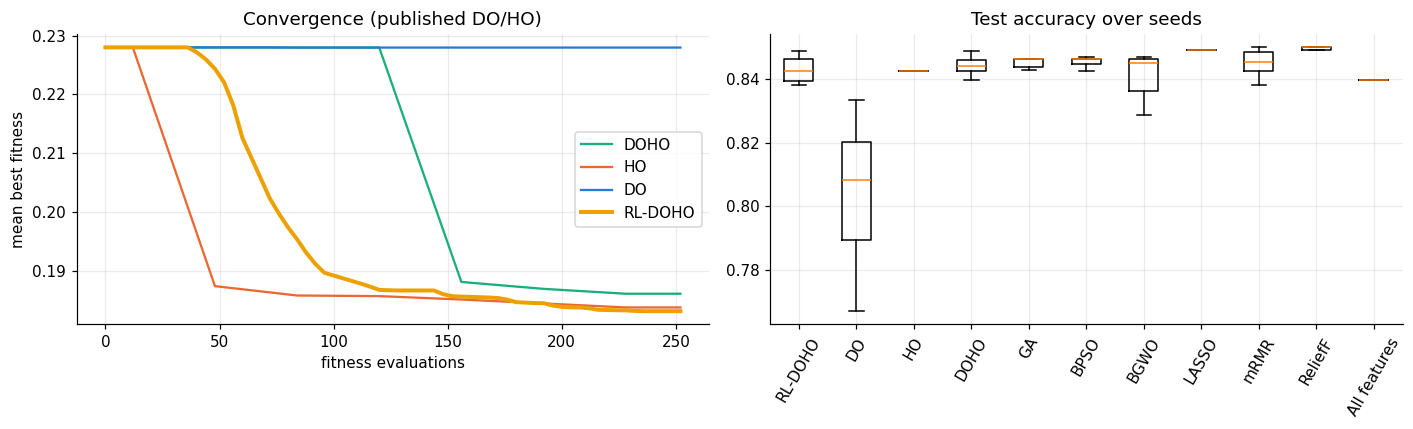

Selection frequency per feature (fraction of seeds):
            RL-DOHO   DO   HO  DOHO
Age             0.8  0.2  0.9   0.7
ESR             1.0  1.0  1.0   1.0
CRP             1.0  0.7  1.0   1.0
RF              1.0  0.9  1.0   1.0
Anti-CCP        1.0  0.8  1.0   1.0
C3              1.0  0.8  1.0   1.0
C4              1.0  0.9  1.0   1.0
Gender          1.0  0.4  0.9   1.0
HLA-B27         0.9  0.7  0.8   0.8
ANA             1.0  0.7  1.0   1.0
Anti-Ro         1.0  0.6  1.0   1.0
Anti-La         1.0  0.6  1.0   1.0
Anti-dsDNA      0.2  0.4  0.1   0.7
Anti-Sm         0.3  0.4  0.9   0.5

Bandit decisions per run: 9.4
Share of UCB-driven choices: {'PERTURB': 0.35, 'HO': 0.31, 'DO': 0.17, 'RESTART': 0.17}
         pulls  mean_reward  total_gain
arm                                    
DO          19       0.0737      0.0000
HO          27       0.3262      0.3609
PERTURB     29       0.2798      0.0875
RESTART     19       0.0000      0.0000


In [15]:
grid = np.linspace(0, BUDGET, 64)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a in FAMILY[::-1]:
    H = [np.interp(grid, runs[("Rheumatic", a, s)]["hist"]["evals"], runs[("Rheumatic", a, s)]["hist"]["best"]) for s in SEEDS if ("Rheumatic", a, s) in runs]
    ax[0].plot(grid, np.mean(H, 0), color=COLORS[a], lw=2.6 if a == "RL-DOHO" else 1.5, label=a)
ax[0].set_xlabel("fitness evaluations"); ax[0].set_ylabel("mean best fitness"); ax[0].legend(); ax[0].set_title("Convergence (published DO/HO)")
data = [R[R.method == m]["test_acc"].values for m in METHODS]
ax[1].boxplot(data, showfliers=False); ax[1].set_xticks(range(1, len(METHODS) + 1)); ax[1].set_xticklabels(METHODS, rotation=60)
ax[1].set_title("Test accuracy over seeds")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v2_convergence_and_accuracy.png", bbox_inches="tight"); plt.show()

freq = pd.DataFrame({a: np.mean([runs[("Rheumatic", a, s)]["mask"] for s in SEEDS if ("Rheumatic", a, s) in runs], axis=0) for a in FAMILY}, index=FEATURES)
print("Selection frequency per feature (fraction of seeds):"); print(freq.round(1).to_string())

ARM = pd.concat([runs[k]["arms"].assign(seed=k[2]) for k in runs if k[1] == "RL-DOHO" and runs[k]["arms"] is not None])
if len(ARM):
    print("\nBandit decisions per run:", round(len(ARM) / ARM.seed.nunique(), 1))
    print("Share of UCB-driven choices:", ARM[ARM.how == "u"].arm.value_counts(normalize=True).round(2).to_dict())
    print(ARM.groupby("arm").agg(pulls=("reward", "size"), mean_reward=("reward", "mean"), total_gain=("gain", "sum")).round(4))

## 15. Summary
Per-run results: `v2_runs.pkl`, `v2_ablation.pkl`, `v2_long.pkl`. Statistics: `v2_stats.csv`. All files are in `OUT_DIR`.

In [16]:
from google.colab import drive, files
import os, zipfile
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive'
FOLDERS = ['rl_doho_results_v2_rheum', 'rl_doho_results_v2_genes']
out = '/content/rl_doho_v2_bundle.zip'
n = 0
with zipfile.ZipFile(out, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in FOLDERS:
        for dp, _, fns in os.walk(os.path.join(ROOT, f)):
            if '/data' in dp:                                  # skip copied raw datasets
                continue
            for fn in fns:
                if fn.startswith(('cache_', 'fitness_cache')):  # skip large fitness caches
                    continue
                p = os.path.join(dp, fn)
                z.write(p, os.path.relpath(p, ROOT)); n += 1
                print(os.path.relpath(p, ROOT), f'{os.path.getsize(p)/1e6:.2f} MB')
print(f'\n{n} files -> {out}  ({os.path.getsize(out)/1e6:.1f} MB)')
files.download(out)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
rl_doho_results_v2_rheum/v2_summary.csv 0.00 MB
rl_doho_results_v2_rheum/v2_stats.csv 0.00 MB
rl_doho_results_v2_rheum/v2_runs.pkl 0.06 MB
rl_doho_results_v2_rheum/v2_ablation.pkl 0.13 MB
rl_doho_results_v2_rheum/v2_long.pkl 0.18 MB
rl_doho_results_v2_rheum/v2_convergence_and_accuracy.png 0.07 MB
rl_doho_results_v2_genes/v2_runs.pkl 1.24 MB
rl_doho_results_v2_genes/v2_stats_per_dataset.csv 0.01 MB
rl_doho_results_v2_genes/v2_stats_pooled.csv 0.00 MB
rl_doho_results_v2_genes/v2_summary.csv 0.01 MB
rl_doho_results_v2_genes/v2_ablation.pkl 1.42 MB
rl_doho_results_v2_genes/v2_convergence.png 0.13 MB
rl_doho_results_v2_genes/v2_boxplots.png 0.12 MB
rl_doho_results_v2_genes/v2_long.pkl 2.01 MB

14 files -> /content/rl_doho_v2_bundle.zip  (1.3 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>